# GNN for Graph Level Predictions about Knots

Juan José H. Beltrán

In [1]:
# Requirements:
# pip install numpy pandas scikit-learn torch torch_geometric matplotlib

In [2]:
import dataset
from torch_geometric.loader import DataLoader
from settings import *

## Create Dataset and Dataloader

In [3]:
train_loader, val_loader, deg, knot_dataset = dataset.load()

# Esto debería pasarse a dataset.py
testGeneralisazion = DataLoader(dataset.fetchDataset("datasets/meanAbove71WithGraph.csv")["dataPoint"], batch_size = BATCH_SIZE)

Dataset consists of  2381 train samples and  596 test samples
max_degree: 11


### Explore Dataset

Cada dataset contiene una fila por cada grafo. Cada grafo tiene a su vez:
- `x`: Tensor con las features de los nodos. En este caso contiene el grado del nodo (input features: 1).
- `edge_index`: Tensor con la descripción de las aristas del grafo, especificando su origen y destino.
- `edge_atrr`: Tensor con los atributos de cada arista del grafo. En este caso son la "distancia" y si está o no "alternando".
- `y`: Tensor con los labels. En este caso, es un único label para todo el grafo: el invariante a predecir.

In [4]:
knot_dataset = knot_dataset.dataPoint

In [5]:
knot_dataset[0].edge_index

tensor([[0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 5, 5],
        [3, 2, 4, 4, 2, 3, 0, 1, 5, 0, 1, 5, 0, 1, 2, 3]])

In [6]:
knot_dataset[0].x

tensor([[3.],
        [3.],
        [3.],
        [3.],
        [2.],
        [2.]])

## Functions and Classes for GNN

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.optim.lr_scheduler import ReduceLROnPlateau
from settings import *

In [8]:
# Import custom GNN models from models.py
from models import PNAKnotNet
from models import GATKnotNet
from models import TransKnotNet

In [9]:
torch.manual_seed(31)
model = TransKnotNet(deg)

optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
scheduler = ReduceLROnPlateau(optimizer, mode = 'min', factor = 0.5, patience = 20, min_lr = 0.00001)

In [10]:
def train(epoch):
    model.train()

    total_loss = 0
    for data in train_loader:
        optimizer.zero_grad()
        if ADDITIONAL:
            out = model(data.x, data.edge_index, data.edge_attr, data.batch, data.featureEncoding)
        else:
            out = model(data.x, data.edge_index, data.edge_attr, data.batch)

        if LOSS == "abs":
            loss = (out.squeeze() - data.y).abs().mean()
        elif LOSS == "squared":
            loss = (out.squeeze() - data.y).square().mean()

        loss.backward()
        total_loss += loss.item() * data.num_graphs
        optimizer.step()

    return total_loss / len(train_loader.dataset)

In [11]:
@torch.no_grad()
def test(loader):
    model.eval()

    total_error = 0
    total_accuracy = torch.tensor(.0)
    for data in loader:
        if ADDITIONAL:
            out = model(data.x, data.edge_index, data.edge_attr, data.batch, data.featureEncoding)
        else:
            out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        
        total_accuracy += (out.squeeze().round()==data.y).sum()#/len(out.squeeze())
        if LOSS=="abs":
            total_error += (out.squeeze() - data.y).abs().sum().item()
        elif LOSS=="squared":
            total_error += (out.squeeze() - data.y).square().sum().item()
    
    return total_error / len(loader.dataset), total_accuracy/ len(loader.dataset)

## Train Model

In [12]:
history_train_loss = []
history_val_loss = []
history_val_acc=[]
history_gen_loss = []
history_gen_acc = []

for epoch in range(1, 200):
    val_loss, val_acc = test(val_loader)
    # gen_loss, gen_acc = test(testGeneralisazion)
    loss = train(epoch)

    # Append history for plotting later
    history_train_loss.append(loss)
    history_val_loss.append(val_loss)
    history_val_acc.append(val_acc)
    # history_gen_loss.append(gen_loss)
    # history_gen_acc.append(gen_acc)

    scheduler.step(loss)
    print(f'Epoch: {epoch:02d}, Loss: {loss:.4f}, Val loss: {val_loss:.4f}, Acc: {val_acc:.4f}')
    # print(f'Epoch: {epoch:02d}, Loss: {loss:.4f}, Val: {val_loss:.4f}, Acc: {val_acc:.4f}, Val on big: {gen_loss:.4f}, Acc on big: {gen_acc:.4f}')

RuntimeError: The size of tensor a (20579976) must match the size of tensor b (1737) at non-singleton dimension 0

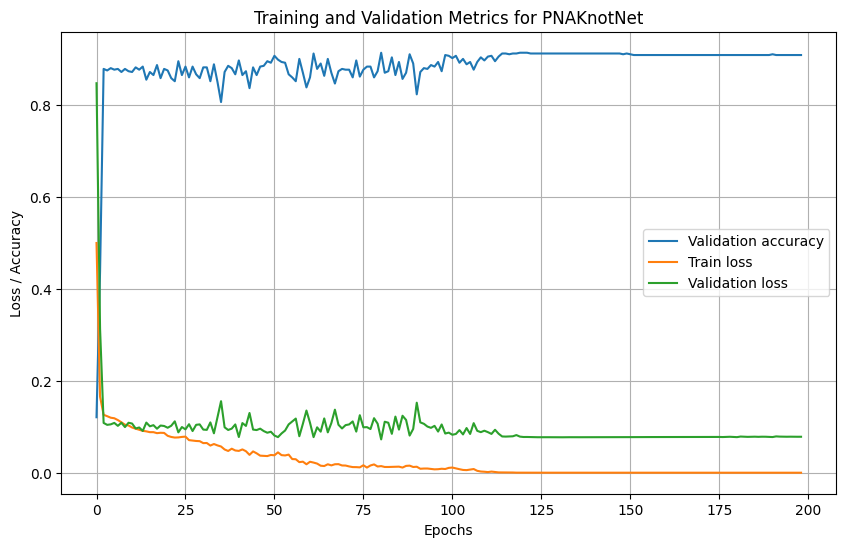

In [ ]:
# Show graphs of loss and accuracy
plt.figure(figsize=(10, 6))
plt.grid()
plt.plot(history_val_acc, label = "Validation accuracy")
plt.plot(history_train_loss, label = "Train loss")
plt.plot(history_val_loss, label = "Validation loss")
# plt.plot(history_gen_acc, label = "Generalization accuracy")
# plt.plot(history_gen_loss, label = "Generalization loss")

plt.title(f"Training and Validation Metrics for {model._get_name()}")
plt.xlabel("Epochs")
plt.ylabel("Loss / Accuracy")
plt.legend()
plt.show()